# 03 Clustering: KMeans, DBSCAN, GMM, Hierarchical

This notebook trains multiple clustering models and compares them using standard unsupervised metrics.

**Input:**
- `outputs/customer_features.csv`
- `outputs/X_scaled.npy`

**Output:**
- `outputs/clustering_metrics_comparison.csv`
- `outputs/customer_clusters_all_models.csv`
- `outputs/customer_clusters_best_model.csv`
- `outputs/clustering_visualizations/` (per-model PCA/t-SNE figures and metrics overview; enable with `SAVE_VIZ` in the viz cell)

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

In [ ]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"

CUSTOMER_PATH = OUTPUT_DIR / "customer_features.csv"
XSCALED_PATH = OUTPUT_DIR / "X_scaled.npy"
FEATURES_JSON_PATH = OUTPUT_DIR / "feature_columns.json"

print("Customer path exists:", CUSTOMER_PATH.exists())
print("X_scaled path exists:", XSCALED_PATH.exists())
print("Features json exists:", FEATURES_JSON_PATH.exists())

Customer path exists: True
X_scaled path exists: True
Features json exists: True


In [ ]:
customer = pd.read_csv(CUSTOMER_PATH)
X_scaled = np.load(XSCALED_PATH)

if FEATURES_JSON_PATH.exists():
    feature_cols = json.loads(FEATURES_JSON_PATH.read_text(encoding="utf-8"))
else:
    feature_cols = []

print("customer shape:", customer.shape)
print("X_scaled shape:", X_scaled.shape)
print("feature_cols:", feature_cols)
customer.head()

customer shape: (1000, 12)
X_scaled shape: (1000, 9)
feature_cols: ['recency_days', 'frequency_count', 'monetary_total', 'avg_order_value', 'weekend_ratio', 'lunch_ratio', 'snacks_ratio', 'dinner_ratio', 'avg_customer_age']


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M


In [ ]:
def clustering_metrics(X, labels):
    labels = np.array(labels)
    unique = np.unique(labels)

    # For DBSCAN, ignore noise for metrics where necessary
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]

    if len(unique) <= 1 or valid_mask.sum() < 2 or len(np.unique(valid_labels)) <= 1:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "n_clusters": int(len([u for u in unique if u != -1])),
            "noise_points": int((labels == -1).sum()),
        }

    X_eval = X[valid_mask]
    return {
        "silhouette": float(silhouette_score(X_eval, valid_labels)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, valid_labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, valid_labels)),
        "n_clusters": int(len([u for u in unique if u != -1])),
        "noise_points": int((labels == -1).sum()),
    }

In [ ]:
# Train clustering models
results = []
labels_map = {}

# KMeans
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init="auto")
labels_map["KMeans"] = kmeans.fit_predict(X_scaled)
results.append({"model": "KMeans", **clustering_metrics(X_scaled, labels_map["KMeans"]), "params": {"n_clusters": 5}})

# DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=8)
labels_map["DBSCAN"] = dbscan.fit_predict(X_scaled)
results.append({"model": "DBSCAN", **clustering_metrics(X_scaled, labels_map["DBSCAN"]), "params": {"eps": 0.9, "min_samples": 8}})

# GMM
gmm = GaussianMixture(n_components=5, random_state=RANDOM_STATE)
labels_map["GMM"] = gmm.fit_predict(X_scaled)
results.append({"model": "GMM", **clustering_metrics(X_scaled, labels_map["GMM"]), "params": {"n_components": 5}})

# Hierarchical
hier = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_map["Hierarchical"] = hier.fit_predict(X_scaled)
results.append({"model": "Hierarchical", **clustering_metrics(X_scaled, labels_map["Hierarchical"]), "params": {"n_clusters": 5, "linkage": "ward"}})

metrics_df = pd.DataFrame(results)
metrics_df["params"] = metrics_df["params"].apply(json.dumps)
metrics_df

,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_points,params
0,KMeans,0.246878,1.494063,224.047501,5,0,"{""n_clusters"": 5}"
1,DBSCAN,0.225461,1.052114,113.265972,9,317,"{""eps"": 0.9, ""min_samples"": 8}"
2,GMM,0.221913,1.826420,173.875648,5,0,"{""n_components"": 5}"
3,Hierarchical,0.244832,1.443058,218.606051,5,0,"{""n_clusters"": 5, ""linkage"": ""ward""}"


In [ ]:
# Compare models (higher silhouette and calinski, lower davies are better)
metrics_sorted = metrics_df.sort_values(["silhouette", "calinski_harabasz"], ascending=False)
metrics_sorted

,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_points,params
0,KMeans,0.246878,1.494063,224.047501,5,0,"{""n_clusters"": 5}"
3,Hierarchical,0.244832,1.443058,218.606051,5,0,"{""n_clusters"": 5, ""linkage"": ""ward""}"
1,DBSCAN,0.225461,1.052114,113.265972,9,317,"{""eps"": 0.9, ""min_samples"": 8}"
2,GMM,0.221913,1.826420,173.875648,5,0,"{""n_components"": 5}"


In [ ]:
# Save all model labels in one table
all_labels_df = customer.copy()
for model_name, labels in labels_map.items():
    all_labels_df[f"cluster_{model_name.lower()}"] = labels

all_labels_path = OUTPUT_DIR / "customer_clusters_all_models.csv"
all_labels_df.to_csv(all_labels_path, index=False)
print("Saved:", all_labels_path)
all_labels_df.head()

Saved: S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\customer_clusters_all_models.csv


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,cluster_kmeans,cluster_dbscan,cluster_gmm,cluster_hierarchical
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,2,-1,2,4
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,2,0,2,0
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,2,0,2,0
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,1,1,1,1
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,4,-1,4,3


In [ ]:
# Choose best model (auto by silhouette, but you can override)
auto_best = metrics_sorted.iloc[0]["model"]
print("Auto-selected best model:", auto_best)

# Override if needed for business interpretability
best_model = auto_best
# best_model = "KMeans"

best_labels = labels_map[best_model]
customer_best = customer.copy()
customer_best["best_model"] = best_model
customer_best["cluster_label"] = best_labels

best_path = OUTPUT_DIR / "customer_clusters_best_model.csv"
customer_best.to_csv(best_path, index=False)
print("Saved:", best_path)
customer_best.head()

Auto-selected best model: KMeans
Saved: S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\customer_clusters_best_model.csv


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,best_model,cluster_label
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,KMeans,2
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,KMeans,2
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,KMeans,2
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,KMeans,1
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,KMeans,4


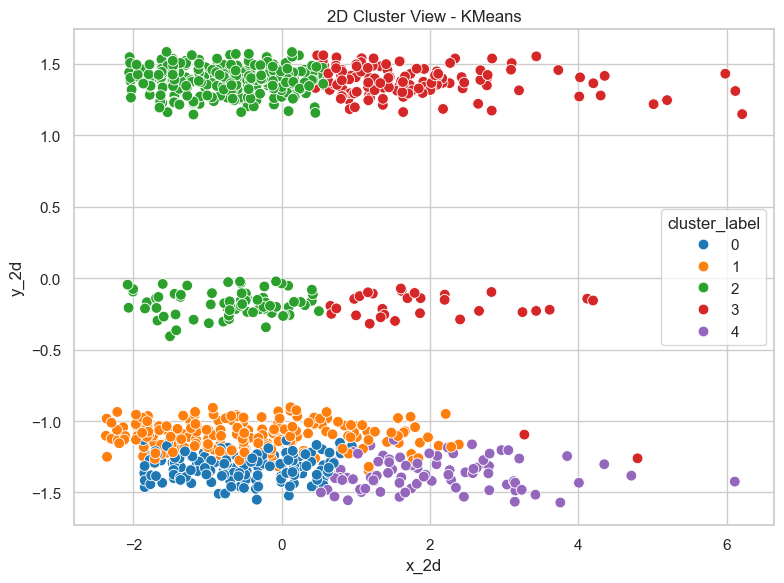

In [ ]:
# Visual exploration: one figure per model (shared PCA / t-SNE for fair comparison)
from sklearn.manifold import TSNE

MODEL_ORDER = ["KMeans", "DBSCAN", "GMM", "Hierarchical"]
SAVE_VIZ = True
VIZ_DIR = OUTPUT_DIR / "clustering_visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Same 2D projections for every model so plots are comparable
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_viz.fit_transform(X_scaled)
pca_var = pca_viz.explained_variance_ratio_.sum()

print("Fitting t-SNE (nonlinear 2D view; may take a minute)...")
tsne_viz = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    init="pca",
)
X_tsne = tsne_viz.fit_transform(X_scaled)


def labels_for_legend(labels: np.ndarray) -> np.ndarray:
    """DBSCAN noise (-1) shown as 'Noise'; others as string cluster ids."""
    labels = np.asarray(labels)
    return np.where(labels == -1, "Noise", labels.astype(str))


def cluster_order_and_colors(labels: np.ndarray):
    """Category order (numeric clusters then Noise) and matching colors."""
    lab = labels_for_legend(labels)
    un = np.unique(lab)
    clusters = sorted([c for c in un if c != "Noise"], key=int)
    order_keys = clusters + (["Noise"] if "Noise" in un else [])
    n_cls = len(clusters)
    colors = list(sns.color_palette("tab10", n_colors=max(n_cls, 3)))
    if "Noise" in order_keys:
        colors = colors[:n_cls] + [(0.55, 0.55, 0.55)]
    return lab, order_keys, colors


def scatter_clusters(ax, emb: np.ndarray, labels: np.ndarray, title: str) -> None:
    lab, order_keys, colors = cluster_order_and_colors(labels)
    plot_df = pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "cluster": lab})
    plot_df["cluster"] = pd.Categorical(plot_df["cluster"], categories=order_keys, ordered=True)

    sns.scatterplot(
        data=plot_df,
        x="x",
        y="y",
        hue="cluster",
        palette=colors,
        ax=ax,
        s=46,
        alpha=0.88,
        edgecolor="white",
        linewidth=0.35,
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")


# --- Overview: compare metrics across models ---
melt_metrics = metrics_df.melt(
    id_vars=["model"],
    value_vars=["silhouette", "davies_bouldin", "calinski_harabasz"],
    var_name="metric",
    value_name="value",
)
fig_overview, axes_ov = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes_ov, ["silhouette", "davies_bouldin", "calinski_harabasz"]):
    sub = melt_metrics[melt_metrics["metric"] == metric].copy()
    sub["model"] = pd.Categorical(sub["model"], categories=MODEL_ORDER, ordered=True)
    sns.barplot(data=sub, x="model", y="value", hue="model", palette="Set2", ax=ax, legend=False)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
fig_overview.suptitle("Clustering metrics by model", fontsize=13, y=1.02)
fig_overview.tight_layout()
if SAVE_VIZ:
    fig_overview.savefig(VIZ_DIR / "metrics_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

profile_feats = [
    c
    for c in ["monetary_total", "frequency_count", "recency_days", "avg_order_value"]
    if c in customer.columns
]

# --- One detailed figure per algorithm ---
for model_name in MODEL_ORDER:
    labels = labels_map[model_name]
    row = metrics_df.loc[metrics_df["model"] == model_name].iloc[0]
    _, order_keys, col_list = cluster_order_and_colors(labels)

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 11))
    subtitle = (
        f"silhouette={row['silhouette']:.4f}  |  "
        f"Davies-Bouldin={row['davies_bouldin']:.4f}  |  "
        f"Calinski-Harabasz={row['calinski_harabasz']:.2f}  |  "
        f"n_clusters={int(row['n_clusters'])}  |  noise_pts={int(row['noise_points'])}"
    )
    fig.suptitle(f"{model_name}\n{subtitle}", fontsize=12)

    scatter_clusters(
        axes[0, 0],
        X_pca,
        labels,
        f"PCA (explained variance ~ {pca_var:.1%})",
    )
    scatter_clusters(axes[0, 1], X_tsne, labels, "t-SNE")

    lab_series = pd.Series(labels_for_legend(labels), name="cluster")
    vc = lab_series.value_counts()
    ord_counts = [k for k in order_keys if k in vc.index]
    counts = vc.reindex(ord_counts)
    sns.barplot(x=counts.values, y=[str(k) for k in ord_counts], ax=axes[1, 0], color="steelblue")
    axes[1, 0].set_title("Cluster sizes (n customers)")
    axes[1, 0].set_xlabel("count")

    prof = customer.loc[:, profile_feats].copy()
    prof["_cluster"] = lab_series.values
    heat = prof.groupby("_cluster")[profile_feats].mean()
    heat_idx = [k for k in order_keys if k in heat.index]
    heat = heat.reindex(heat_idx)
    sns.heatmap(heat.T, annot=True, fmt=".1f", cmap="crest", ax=axes[1, 1], cbar_kws={"label": "mean"})
    axes[1, 1].set_title("Mean profile by cluster")
    axes[1, 1].set_xlabel("cluster")
    axes[1, 1].set_ylabel("")

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=col_list[i],
            markersize=8,
            label=str(order_keys[i]),
        )
        for i in range(len(order_keys))
    ]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Cluster", frameon=True)

    fig.tight_layout(rect=[0, 0, 0.88, 0.94])
    if SAVE_VIZ:
        safe = model_name.lower().replace(" ", "_")
        fig.savefig(VIZ_DIR / f"clusters_{safe}.png", dpi=160, bbox_inches="tight")
    plt.show()

print("Figures saved under:", VIZ_DIR if SAVE_VIZ else "(disabled)")


In [ ]:
# Cluster profile summary
profile_cols = [c for c in ["frequency_count", "monetary_total", "avg_order_value", "recency_days", "weekend_ratio", "lunch_ratio"] if c in customer_best.columns]

cluster_summary = customer_best.groupby("cluster_label")[profile_cols].mean().round(3)
cluster_summary["customers"] = customer_best.groupby("cluster_label").size()
cluster_summary = cluster_summary.reset_index()
cluster_summary

,cluster_label,frequency_count,monetary_total,avg_order_value,recency_days,weekend_ratio,lunch_ratio,customers
0,0,1.0,94.798,94.798,91.822,0.178,0.000,163
1,1,1.0,125.374,125.374,88.752,0.257,0.000,222
2,2,1.0,94.427,94.427,89.104,0.187,0.808,375
3,3,1.0,248.108,248.108,93.044,0.437,0.797,158
4,4,1.0,244.720,244.720,81.110,0.537,0.000,82


In [ ]:
# Save outputs
metrics_path = OUTPUT_DIR / "clustering_metrics_comparison.csv"
summary_path = OUTPUT_DIR / "cluster_profile_summary.csv"

metrics_df.to_csv(metrics_path, index=False)
cluster_summary.to_csv(summary_path, index=False)

print("Saved files:")
print("-", metrics_path)
print("-", all_labels_path)
print("-", best_path)
print("-", summary_path)

Saved files:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\clustering_metrics_comparison.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\customer_clusters_all_models.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\customer_clusters_best_model.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\cluster_profile_summary.csv


## Next Notebook

Move to `04_model_evaluation_and_selection.ipynb` to finalize model selection logic and create presentable model comparison visuals for your report/demo.